# Denoising AutoEncoder Anomaly Detector
Loss func: SSIM

Denoising: Adds noise to the input data before training. Reconstruction loss uses unaltered input.

In [ ]:
# Download the dataset, setup packages
# SSIM download
!pip install torchmetrics
import os
import cv2
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import random
from sklearn.metrics import accuracy_score, roc_auc_score

import torch as torch
import torch.nn as nn
import torch.optim as optim
# SSIM addition
from torchmetrics.image import StructuralSimilarityIndexMeasure

if not os.path.exists('dataset.zip'):
  !gdown 1_pRKXtYRjWjY0seYqyx25nOxjtr-mHYg
  !unzip -q -u dataset.zip
else:
  print('Already downloaded')

Already downloaded


In [ ]:
# Some helper functions
def load_dataset(class_name = 'pasta'):
  assert class_name in ['pasta', 'screws', 'capsule']
  dir = './dataset/'+class_name+'/'
  training_images = []
  testing_images = []
  testing_labels = []
  for file_name in os.listdir(dir+'train/good/'):
    training_images.append(cv2.cvtColor(cv2.imread(dir+'train/good/'+file_name), cv2.COLOR_BGR2RGB))
  for file_name in os.listdir(dir+'test/good/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/good/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(0)
  for file_name in os.listdir(dir+'test/bad/'):
    testing_images.append(cv2.cvtColor(cv2.imread(dir+'test/bad/'+file_name), cv2.COLOR_BGR2RGB))
    testing_labels.append(1)

  # returns a normalized (0-1) numpy array of size (n,)
  return np.array(training_images)/255., np.array(testing_images)/255., np.array(testing_labels)

def basic_evaluation(predictions : np.ndarray, targets : np.ndarray):
  print(targets)
  print(predictions)
  print('AUROC Score:', roc_auc_score(targets, predictions))

In [ ]:
# Made with AI
def set_seed(seed=77):
    """Locks down all random number generators for reproducibility."""
    # 1. Python built-in random module
    random.seed(seed)

    # 2. NumPy (This fixes your np.random.choice issue!)
    np.random.seed(seed)

    # 3. PyTorch (CPU and GPU)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 4. CuDNN (GPU backend)
    # Note: Forcing deterministic behavior can slightly slow down training
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Call this immediately!
set_seed(77)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, image_height, image_width, latent_vector_dim=8):

        # Tighter bottleneck forces the model to compress harder
        # widens the reconstruction gap between normal and anomalous images.

        super().__init__()

        self.convolution = nn.Sequential(

            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(32, affine = True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(64, affine = True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(128, affine = True),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(256, affine = True),
        )

        # Dummy pass
        dummy_input = torch.zeros(1, 3, image_height, image_width)
        dummy_output = self.convolution(dummy_input)

        self.flattened_size = dummy_output.view(1, -1).size(1)
        self.spatial_shape = dummy_output.shape[1:]

        self.fc = nn.Linear(self.flattened_size, latent_vector_dim)

    def forward(self, x):
        z = self.convolution(x)
        x = torch.flatten(z, start_dim=1)
        latent_vector = self.fc(x)
        return latent_vector


In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_vector_dim, flattened_size, spatial_shape):
        super().__init__()
        self.spatial_shape = spatial_shape

        self.fully_connected_decoder_in = nn.Linear(latent_vector_dim, flattened_size)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, self.spatial_shape),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(128, affine = True),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(64, affine = True),

            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.InstanceNorm2d(32, affine = True),

            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fully_connected_decoder_in(z)
        output = self.decoder(x)
        return output

In [ ]:
def calc_loss(x, recon_out, ssim_metric):

  ssim_score = ssim_metric(recon_out, x)

  # A perfect reconstruction gives SSIM = 1 . Therefore to make this a loss function we do 1-1.

  reconstruction_loss = 1.0 - ssim_score

  return reconstruction_loss

In [ ]:
class Basic_AE(nn.Module):
  def __init__(self, image_height, image_width, latent_vector_dim = 8, num_epochs=30):
    super().__init__()

    self.encoder = Encoder(image_height, image_width)

    self.decoder = Decoder(latent_vector_dim, self.encoder.flattened_size, self.encoder.spatial_shape)

  def forward(self, x):
    lv = self.encoder(x)
    reconstructed_output = self.decoder(lv)

    return reconstructed_output


In [ ]:
# made with ai
def generate_anomaly_heatmap(original, reconstructed):
    """
    original, reconstructed: tensors of shape (N, C, H, W)
    returns: heatmaps (N, H, W)
    """
    # Pixel-wise squared error
    error = (original - reconstructed) ** 2

    # Collapse RGB → single channel
    heatmap = torch.mean(error, dim=1)  # (N, H, W)

    return heatmap

In [ ]:
# made with AI
def visualize_reconstructions(model, test_data, num_images=5):
    """Passes a few test images through the model and plots the original vs. reconstruction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Grab a few random images from the test set
    indices = np.random.choice(len(test_data), num_images, replace=False)
    sample_images = test_data[indices]

    # Convert to PyTorch tensor and fix dimensions for model (N, C, H, W)
    x = torch.tensor(sample_images).permute(0, 3, 1, 2).float().to(device)

    #x = torch.clamp(x, 0., 1.)

    with torch.no_grad():
        reconstructed = model(x)

    heatmaps = generate_anomaly_heatmap(x, reconstructed)
    # Move back to CPU and format for matplotlib (N, H, W, C)
    recon_images = reconstructed.permute(0, 2, 3, 1).cpu().numpy()
    heatmaps = heatmaps.cpu().numpy()

    # Plotting
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))
    fig.suptitle("Original vs Reconstructed", fontsize=16)

    for i in range(num_images):
        # Original Image
        axes[i, 0].imshow(sample_images[i])
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Reconstructed Image
        axes[i, 1].imshow(recon_images[i])
        axes[i, 1].set_title("Reconstructed")
        axes[i, 1].axis('off')

        # heat map?
        axes[i, 2].imshow(heatmaps[i], cmap = 'hot')
        axes[i, 2].set_title("Heatmap")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def train_model(model, dataset, num_epochs, learning_rate=1e-3, noise_factor=0.4):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # SSIM init ((our image values are 0 to 1))
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    # convert numpy to torch, need to rearrange the dimensions
    x = torch.tensor(dataset).permute(0,3,1,2).float().to(device)

    # Make it noisy
    noisy_x = x + noise_factor * torch.randn(*x.shape).to(device)
    noisy_x = torch.clamp(noisy_x, 0., 1.)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):

      model.train()

      # compute forward pass using the NOISY input
      recon_out = model(noisy_x)

      # compute loss against the OG input
      loss = calc_loss(x, recon_out,ssim_metric)

      # clear old gradients from last iter
      optimizer.zero_grad()

      # backward pass for optimization
      loss.backward()

      # update
      optimizer.step()

      print("epoch",epoch,"loss",loss.item())

def predict(model, test_data):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # Initialize SSIM with reduction='none' to get individual scores per image
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0, reduction='none').to(device)

    x = torch.tensor(test_data).permute(0,3,1,2).float().to(device)

    with torch.no_grad():
        x_hat = model(x)

        # Calculate SSIM for each image
        # (1.0 means perfect match, 0.0 means no match)
        ssim_scores = ssim_metric(x_hat, x)

        # Convert SSIM to an "error" or "anomaly" score (higher = more anomalous)
        errors = 1.0 - ssim_scores

    return errors.cpu().numpy()


screws analysis
epoch 0 loss 0.982795238494873
epoch 1 loss 0.9740333557128906
epoch 2 loss 0.9365512132644653
epoch 3 loss 0.888956606388092
epoch 4 loss 0.8437864780426025
epoch 5 loss 0.8068619966506958
epoch 6 loss 0.7762655019760132
epoch 7 loss 0.7502334713935852
epoch 8 loss 0.7272580862045288
epoch 9 loss 0.7058106064796448
epoch 10 loss 0.6852308511734009
epoch 11 loss 0.6654306650161743
epoch 12 loss 0.6463212966918945
epoch 13 loss 0.6282413601875305
epoch 14 loss 0.6113696098327637
epoch 15 loss 0.59568852186203
epoch 16 loss 0.5811256170272827
epoch 17 loss 0.5676939487457275
epoch 18 loss 0.5554395914077759
epoch 19 loss 0.5442847013473511
epoch 20 loss 0.534078061580658
epoch 21 loss 0.5247142314910889
epoch 22 loss 0.5160790085792542
epoch 23 loss 0.5081361532211304
epoch 24 loss 0.500781774520874
epoch 25 loss 0.49390488862991333
epoch 26 loss 0.48743754625320435
epoch 27 loss 0.4813194274902344
epoch 28 loss 0.4755142331123352
epoch 29 loss 0.4699975848197937
[0 0 0 0

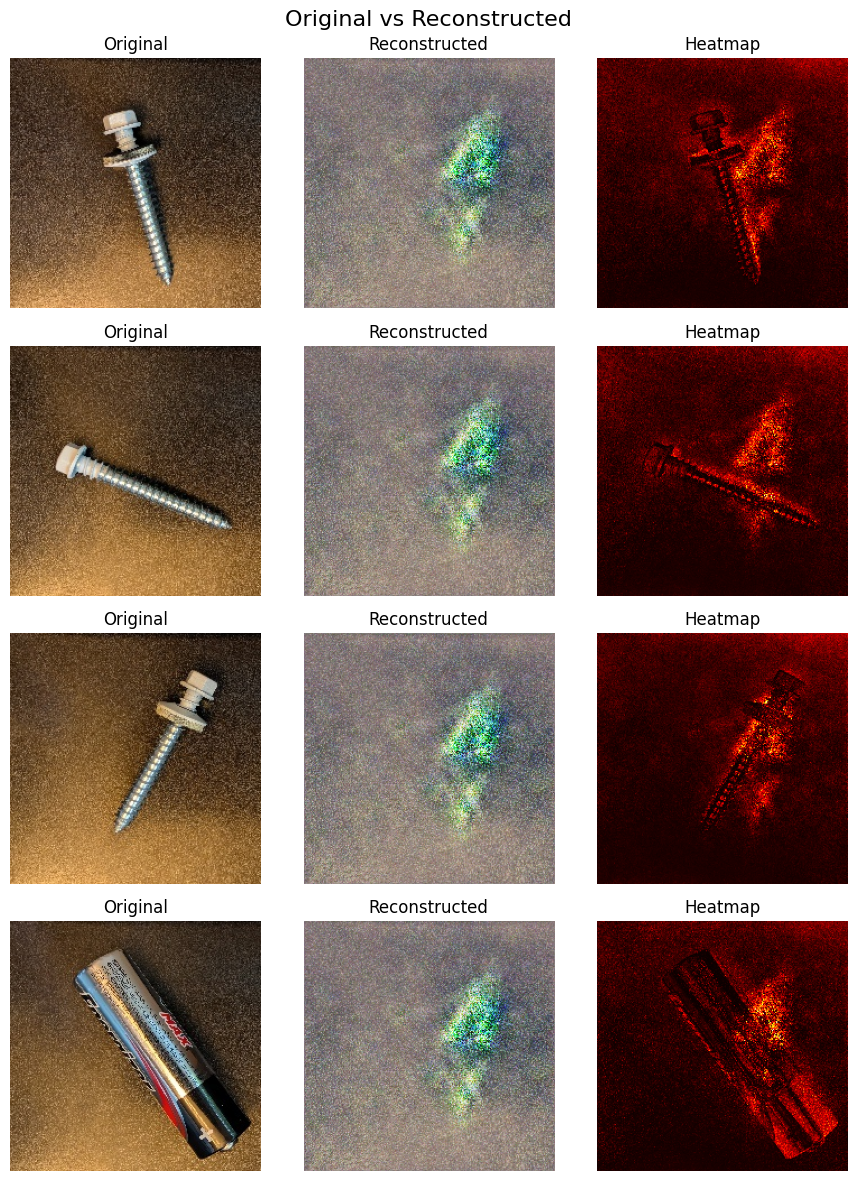

pasta analysis
epoch 0 loss 0.9815382957458496
epoch 1 loss 0.9781337380409241
epoch 2 loss 0.9635112881660461
epoch 3 loss 0.9469060897827148
epoch 4 loss 0.9292078018188477
epoch 5 loss 0.9106048941612244
epoch 6 loss 0.8912439942359924
epoch 7 loss 0.8713587522506714
epoch 8 loss 0.8509722948074341
epoch 9 loss 0.8302072286605835
epoch 10 loss 0.8090947866439819
epoch 11 loss 0.7875314950942993
epoch 12 loss 0.765362560749054
epoch 13 loss 0.742109477519989
epoch 14 loss 0.7168658971786499
epoch 15 loss 0.6888229846954346
epoch 16 loss 0.6582326889038086
epoch 17 loss 0.6277527213096619
epoch 18 loss 0.6010980606079102
epoch 19 loss 0.581230103969574
epoch 20 loss 0.5643896460533142
epoch 21 loss 0.5469635725021362
epoch 22 loss 0.5296952724456787
epoch 23 loss 0.5145108699798584
epoch 24 loss 0.5007104873657227
epoch 25 loss 0.4876931309700012
epoch 26 loss 0.4756532907485962
epoch 27 loss 0.4649982452392578
epoch 28 loss 0.45559900999069214
epoch 29 loss 0.44675588607788086
[0 0 0

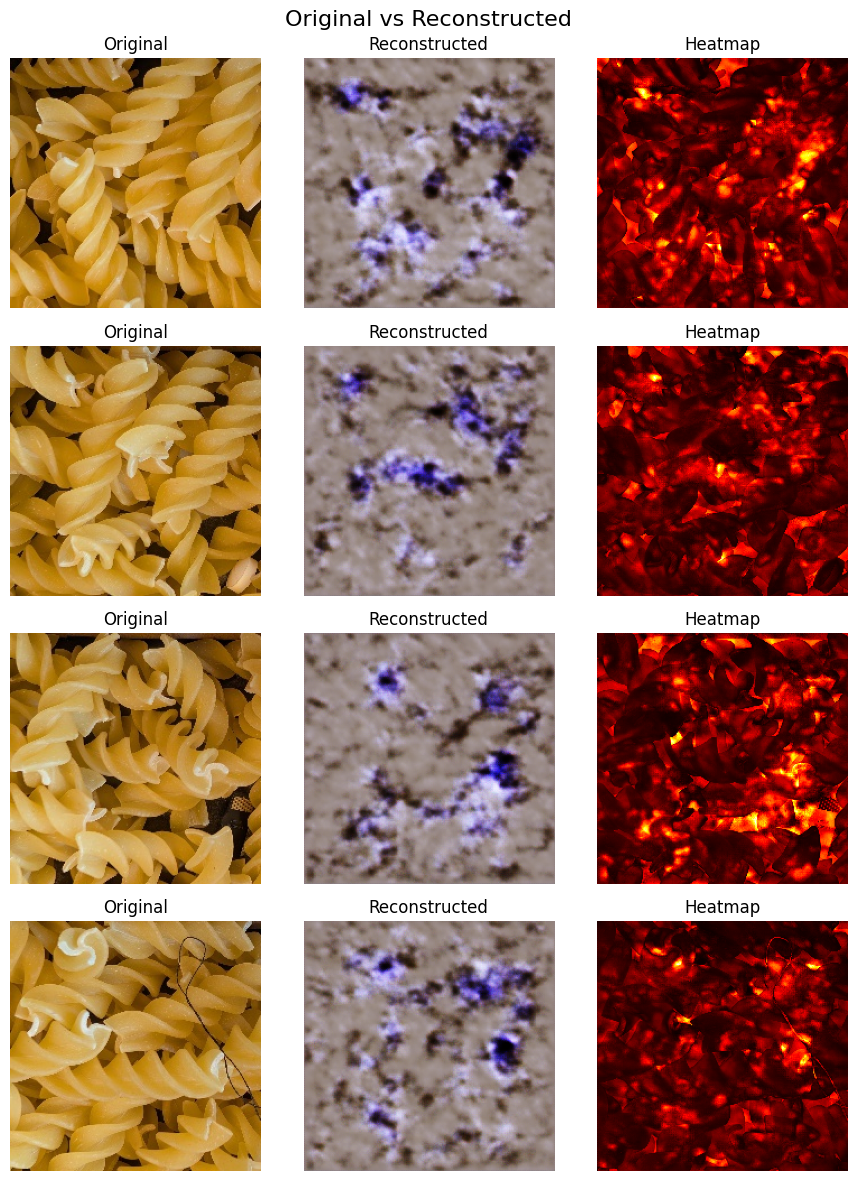

capsule analysis
epoch 0 loss 0.9784733057022095
epoch 1 loss 0.9733843207359314
epoch 2 loss 0.9592952132225037
epoch 3 loss 0.9420320391654968
epoch 4 loss 0.9170075058937073
epoch 5 loss 0.8822014927864075
epoch 6 loss 0.835147500038147
epoch 7 loss 0.7858042120933533
epoch 8 loss 0.7032749652862549
epoch 9 loss 0.6156278252601624
epoch 10 loss 0.5330701470375061
epoch 11 loss 0.4662778377532959
epoch 12 loss 0.4151197671890259
epoch 13 loss 0.3823676109313965
epoch 14 loss 0.35625314712524414
epoch 15 loss 0.3388964533805847
epoch 16 loss 0.3254350423812866
epoch 17 loss 0.31503385305404663
epoch 18 loss 0.3063840866088867
epoch 19 loss 0.2984526753425598
epoch 20 loss 0.2910253405570984
epoch 21 loss 0.2843130826950073


In [ ]:
# Def: Trains model, gets prediction, does evaluations, then visualizes the stages
def do_analysis(class_name):
  training_images, testing_images, testing_labels = load_dataset(class_name=class_name)

  img_height = training_images.shape[1]
  img_width = training_images.shape[2]

  basic_model = Basic_AE(img_height, img_width)

  train_model(basic_model, training_images, num_epochs=30)

  predictions = predict(basic_model, testing_images)
  basic_evaluation(predictions, testing_labels)

  print(f"\nVisualizing sample reconstructions for {class_name}...")
  visualize_reconstructions(basic_model, testing_images, num_images=4)

print("screws analysis")
do_analysis('screws')
print("pasta analysis")
do_analysis('pasta')
print("capsule analysis")
do_analysis('capsule')
